In [4]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Skill_ML/titanic (1).zip'
extract_path = '/content/titanic'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Titanic dataset extracted successfully!")
print("Files: ", os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Titanic dataset extracted successfully!
Files:  ['gender_submission.csv', 'test.csv', 'train.csv']


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/titanic/train.csv')

features = ['Pclass', 'Age', 'SibSp', 'Parch']

data = df[features + ['Fare']].copy()

data['Age'] = data['Age'].fillna(data['Age'].median())

print("Dataset Shape:", data.shape)
display(data.head())

Dataset Shape: (891, 5)


,Pclass,Age,SibSp,Parch,Fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[features]
y = data['Fare']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 712
Testing Samples: 179


In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

print("All three models trained successfully!")

All three models trained successfully!


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred
}

for name, prediction in models.items():
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    print("\n", name)
    print("MSE :", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 4))


 Linear Regression
MSE : 946.34
RMSE: 30.76
R²  : 0.3884

 Ridge Regression
MSE : 945.69
RMSE: 30.75
R²  : 0.3889

 Lasso Regression
MSE : 944.88
RMSE: 30.74
R²  : 0.3894


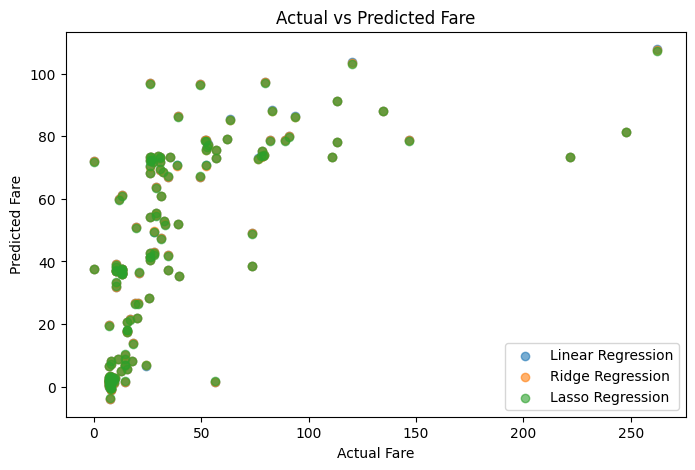


LINEAR REGRESSION AND REGULARISATION COMPLETED


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, linear_pred, alpha=0.6, label='Linear Regression')
plt.scatter(y_test, ridge_pred, alpha=0.6, label='Ridge Regression')
plt.scatter(y_test, lasso_pred, alpha=0.6, label='Lasso Regression')

plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Actual vs Predicted Fare')
plt.legend()
plt.show()

print("\nLINEAR REGRESSION AND REGULARISATION COMPLETED")